
# REINFORCE + Baseline

Use this notebook to train the `ReinforceBaselineAgent` against multiple environments.


In [31]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Any, Callable
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from algorithms.reinforce_baseline.agent import ReinforceBaselineAgent
from mdp.gridworld.gridworld import GridWorldMDP
from mdp.cats_v_monsters.cats_vs_monsters import CatsVMonstersMDP

#TODO add mountain bike

plt.style.use('ggplot')

@dataclass
class EnvSpec:
    name: str
    builder: Callable[[], Any]
    episodes: int
    max_steps: int
    description: str

In [32]:
ENV_REGISTRY = {
    'gridworld': EnvSpec(
        name='GridWorld 5x5',
        builder=lambda: GridWorldMDP(rows=5, cols=5),
        episodes=400,
        max_steps=100,
        description='5x5 grid with goal at (4, 4).'
    ),
    'cats_vs_monsters': EnvSpec(
        name='Cats vs Monsters',
        builder=lambda: CatsVMonstersMDP(rows=5, cols=5),
        episodes=400,
        max_steps=120,
        description='MDP with monsters and food rewards.'
    ),
    #TODO add mountain bike
}

print('Available environments:')
for key,spec in ENV_REGISTRY.items():
    print(f"  - {key} : {spec.description}")


Available environments:
  - gridworld : 5x5 grid with goal at (4, 4).
  - cats_vs_monsters : MDP with monsters and food rewards.


In [33]:
results = {}


In [34]:
def get_state_space(env):
    """Return the environment's valid state space."""
    if hasattr(env, 'get_state_space'):
        states = list(env.get_state_space())
        if states:
            return states
    raise ValueError('Environment must implement get_state_space().')
    
def _make_feature_func(states):
    """Return a callable that maps states to one-hot feature vectors."""

    def to_key(state):
        if state is None:
            return None
        if isinstance(state, tuple):
            return state
        if isinstance(state, list):
            return tuple(state)
        if hasattr(state, "tolist"):
            return tuple(state.tolist())
        return state

    normalized_states = [to_key(state) for state in states]
    state_to_index = {state: i for i, state in enumerate(normalized_states)}
    feature_dim = len(state_to_index)

    def feature_fn(state):
        vector = np.zeros(feature_dim, dtype=np.float64)
        idx = state_to_index.get(to_key(state))
        if idx is not None:
            vector[idx] = 1.0
        return vector

    return feature_fn, feature_dim


def _get_action_space(env):
    if hasattr(env, "get_action_space"):
        return list(env.get_action_space())
    raise AttributeError("Environment must provide get_action_space() or action_space.")


def run_reinforce_experiment(
    env_key,
    *,
    episodes=None,
    max_steps=None,
    agent_config=None,
    log_dir=Path("reinforce_logs"),
):
    """Train a ReinforceBaselineAgent on the environment and report diagnostics."""
    if env_key not in ENV_REGISTRY:
        raise KeyError(f"Unknown environment key: {env_key!r}")

    spec = ENV_REGISTRY[env_key]
    env = spec.builder()
    state_list = get_state_space(env)
    policy_features, feature_dim = _make_feature_func(state_list)
    value_features = policy_features
    action_space = _get_action_space(env)
    episodes = episodes or spec.episodes
    max_steps = max_steps or spec.max_steps

    print(f"\n=== {spec.name} ({env_key}) ===")
    print(f"      States: {len(state_list)}, Actions: {len(action_space)}, Feature dim: {feature_dim}")
    print(f"      Episodes: {episodes}, Max steps/episode: {max_steps}")

    agent = ReinforceBaselineAgent(
        action_space,
        policy_feature_fn=policy_features,
        value_feature_fn=value_features,
        config=agent_config,
    )
    stats, episode_logs = agent.train(env, episodes=episodes, max_steps=max_steps)

    log_dir = Path(log_dir)
    log_dir.mkdir(parents=True, exist_ok=True)
    log_path = log_dir / f"{env_key}_episodes.json"
    payload = {
        "environment_key": env_key,
        "environment_name": spec.name,
        "description": spec.description,
        "episodes": episodes,
        "max_steps": max_steps,
        "logs": episode_logs,
    }
    with log_path.open("w", encoding="utf-8") as fh:
        json.dump(payload, fh, indent=2)
    print(f"      Saved {len(episode_logs)} episode logs to {log_path}")

    returns = [stat.episode_return for stat in stats]
    lengths = [stat.length for stat in stats]
    success_flags = [stat.success for stat in stats]
    positive_counts = [stat.positive_rewards for stat in stats]
    penalty_counts = [stat.penalty_rewards for stat in stats]
    baseline_mse_values = [stat.baseline_mse for stat in stats]

    success_rate = float(np.mean(success_flags)) if success_flags else 0.0
    avg_positive = float(np.mean(positive_counts)) if positive_counts else 0.0
    avg_penalty = float(np.mean(penalty_counts)) if penalty_counts else 0.0
    avg_baseline_mse = float(np.mean(baseline_mse_values)) if baseline_mse_values else 0.0

    print(f"      Success rate: {success_rate * 100:.1f}%")
    print(
        f"      Avg reward components → positive: {avg_positive:.1f}, penalties: {avg_penalty:.1f}"
    )
    print(f"      Avg baseline MSE: {avg_baseline_mse:.4f}")

    return {
        "environment_key": env_key,
        "environment_name": spec.name,
        "description": spec.description,
        "episodes": episodes,
        "max_steps": max_steps,
        "feature_dim": feature_dim,
        "returns": returns,
        "lengths": lengths,
        "success_flags": success_flags,
        "positive_counts": positive_counts,
        "penalty_counts": penalty_counts,
        "baseline_mse": baseline_mse_values,
        "success_rate": success_rate,
        "avg_positive_rewards": avg_positive,
        "avg_penalty_rewards": avg_penalty,
        "avg_baseline_mse": avg_baseline_mse,
        "log_path": str(log_path),
    }


In [35]:
def plot_episode_returns(result_map, *, rolling_window=20, ax=None):
    """Plot raw and smoothed episode returns for one or more experiments."""
    if not result_map:
        raise ValueError("result_map must contain at least one experiment payload.")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    else:
        fig = ax.figure

    for label, payload in result_map.items():
        returns = np.asarray(payload.get('returns', []), dtype=np.float64)
        if returns.size == 0:
            continue
        episodes = np.arange(1, returns.size + 1)
        ax.plot(episodes, returns, alpha=0.3, label=f"{label} (raw)")

        window = max(1, min(rolling_window, returns.size))
        kernel = np.ones(window) / window
        smoothed = np.convolve(returns, kernel, mode='valid')
        smoothed_x = episodes[window - 1:]
        ax.plot(smoothed_x, smoothed, label=f"{label} ({window}-ep avg)")

    ax.set_title('Episode returns')
    ax.set_xlabel('Episode #')
    ax.set_ylabel('Return')
    ax.legend(loc='best')
    ax.grid(True)
    fig.tight_layout()
    return ax


In [36]:
def _line_plot(metric_map, *, label_suffix, ylabel, rolling_window=20, ax=None, title=None):
    """Utility to plot raw and smoothed metrics stored as per-episode lists."""
    if not metric_map:
        raise ValueError("metric_map must contain at least one experiment payload.")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    else:
        fig = ax.figure

    color_cycle = plt.get_cmap('tab10')
    for idx, (label, values) in enumerate(metric_map.items()):
        data = np.asarray(values, dtype=np.float64)
        if data.size == 0:
            continue
        color = color_cycle(idx % 10)
        episodes = np.arange(1, data.size + 1)
        ax.plot(
            episodes,
            data,
            alpha=0.7,
            color=color,
            linestyle='--',
            linewidth=1.5,
            label=f"{label} (raw {label_suffix})",
        )

        window = max(1, min(rolling_window, data.size))
        kernel = np.ones(window) / window
        smoothed = np.convolve(data, kernel, mode='valid')
        smoothed_x = episodes[window - 1:]
        ax.plot(
            smoothed_x,
            smoothed,
            color=color,
            linewidth=2.5,
            label=f"{label} ({window}-ep avg {label_suffix})",
        )

    ax.set_xlabel('Episode #')
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    ax.legend(loc='best')
    ax.grid(True)
    fig.tight_layout()
    return ax


def _prepare_env_axes(result_map):
    env_items = list(result_map.items())
    if not env_items:
        raise ValueError("result_map must contain at least one experiment payload.")
    fig, axes = plt.subplots(len(env_items), 1, figsize=(8, 4 * len(env_items)), sharex=False)
    if len(env_items) == 1:
        axes = [axes]
    return env_items, fig, axes


def plot_reward_components(result_map, *, rolling_window=20):
    """Plot positive vs penalty reward counts per episode for each environment."""
    env_items, fig, axes = _prepare_env_axes(result_map)
    for ax, (label, payload) in zip(axes, env_items):
        metric_map = {
            f"{label} (+)": np.asarray(payload.get('positive_counts', []), dtype=np.float64),
            f"{label} (penalty)": np.asarray(payload.get('penalty_counts', []), dtype=np.float64),
        }
        _line_plot(
            metric_map,
            label_suffix='rewards',
            ylabel='# rewards / episode',
            rolling_window=rolling_window,
            ax=ax,
            title=f"{label}: reward components",
        )
    fig.tight_layout()
    return axes


def plot_success_rate(result_map, *, rolling_window=20):
    """Plot success indicators per environment with smoothing to show success rate."""
    env_items, fig, axes = _prepare_env_axes(result_map)
    for ax, (label, payload) in zip(axes, env_items):
        metric_map = {
            label: np.asarray(payload.get('success_flags', []), dtype=np.float64)
        }
        _line_plot(
            metric_map,
            label_suffix='success',
            ylabel='Success rate',
            rolling_window=rolling_window,
            ax=ax,
            title=f"{label}: success trajectory",
        )
        ax.set_ylim(-0.05, 1.05)
    fig.tight_layout()
    return axes


def plot_baseline_mse(result_map, *, rolling_window=20):
    """Plot per-episode baseline mean-squared error for each environment."""
    env_items, fig, axes = _prepare_env_axes(result_map)
    for ax, (label, payload) in zip(axes, env_items):
        metric_map = {
            label: np.asarray(payload.get('baseline_mse', []), dtype=np.float64)
        }
        _line_plot(
            metric_map,
            label_suffix='baseline MSE',
            ylabel='Baseline MSE',
            rolling_window=rolling_window,
            ax=ax,
            title=f"{label}: baseline MSE",
        )
    fig.tight_layout()
    return axes


## GridWorld 5x5 experiment
Run REINFORCE with baseline on the stochastic GridWorld map.


=== GridWorld 5x5 (gridworld) ===
      States: 25, Actions: 4, Feature dim: 25
      Episodes: 400, Max steps/episode: 100
      Saved 400 episode logs to reinforce_logs/gridworld_episodes.json
      Success rate: 96.8%
      Avg reward components → positive: 1.0, penalties: 0.1
      Avg baseline MSE: 25.9710


{'environment_key': 'gridworld',
 'environment_name': 'GridWorld 5x5',
 'description': '5x5 grid with goal at (4, 4).',
 'episodes': 400,
 'max_steps': 100,
 'feature_dim': 25,
 'returns': [6.298236312032324,
  -19.424703491315977,
  7.936142836436555,
  0.0,
  5.929664464014995,
  5.6390519045238765,
  0.0,
  7.249803359578536,
  0.0,
  7.249803359578536,
  7.249803359578536,
  -15.859988828112334,
  0.0,
  6.894490858690779,
  -49.2923923429161,
  5.416850759668536,
  0.0,
  -41.73632289620262,
  6.825545950103871,
  -24.992006998498056,
  7.034476949995693,
  5.471566423907612,
  4.801414565714213,
  7.249803359578536,
  5.048858887870697,
  6.172901409422881,
  7.397003733882804,
  -9.2274469442792,
  5.309055429551132,
  5.471566423907612,
  8.01630589539046,
  8.17906937597231,
  0.0,
  3.966778064220251,
  4.006846529515405,
  4.006846529515405,
  7.323033696543976,
  7.397003733882804,
  8.429431933839268,
  6.757290490602832,
  0.0,
  6.894490858690779,
  -0.12787970881485883,

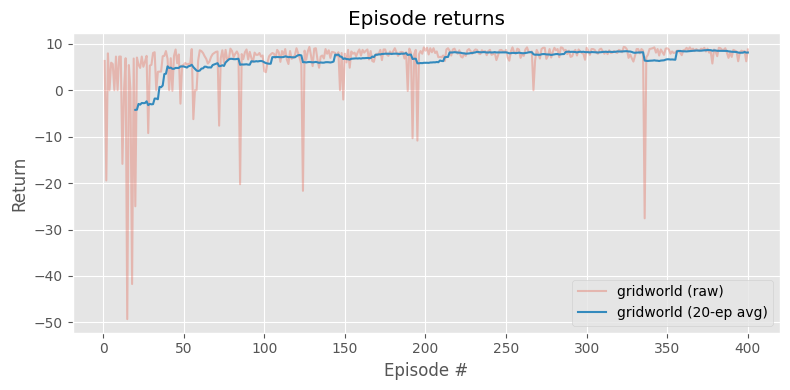

In [37]:
gridworld_result = run_reinforce_experiment('gridworld')
results['gridworld'] = gridworld_result
plot_episode_returns({'gridworld': gridworld_result})

gridworld_result


## Cats vs Monsters experiment
Run REINFORCE with baseline on the Cats vs Monsters grid.


=== Cats vs Monsters (cats_vs_monsters) ===
      States: 25, Actions: 4, Feature dim: 25
      Episodes: 400, Max steps/episode: 120
      Saved 400 episode logs to reinforce_logs/cats_vs_monsters_episodes.json
      Success rate: 99.0%
      Avg reward components → positive: 1.0, penalties: 27.8
      Avg baseline MSE: 64.9510


{'environment_key': 'cats_vs_monsters',
 'environment_name': 'Cats vs Monsters',
 'description': 'MDP with monsters and food rewards.',
 'episodes': 400,
 'max_steps': 120,
 'feature_dim': 25,
 'returns': [-11.735976801950638,
  -41.48676814500824,
  -28.217813079839445,
  -13.378783770413209,
  -15.002947822408636,
  -7.1380625577449495,
  -56.204973817183536,
  -44.96002250498887,
  -26.41776822481241,
  -69.32249818016416,
  -2.218959394471162,
  -2.0256311883103035,
  -30.791920986820113,
  0.8518540751320632,
  -51.97216891193511,
  2.202121848571322,
  -8.507429607709357,
  -26.53555162555031,
  -68.30920612554685,
  -14.063792211137727,
  -1.351269775886009,
  3.373992078217956,
  -2.7326685140747706,
  -0.3388491644190812,
  -0.1859195396916724,
  -10.062089311033725,
  -2.5152706385318333,
  -21.115959607532712,
  -8.827253611872644,
  -51.62806647341659,
  -0.8515661673917251,
  -1.7705934756091355,
  -0.9627588800304483,
  -18.62656178360469,
  -13.099918560051584,
  -6.8634

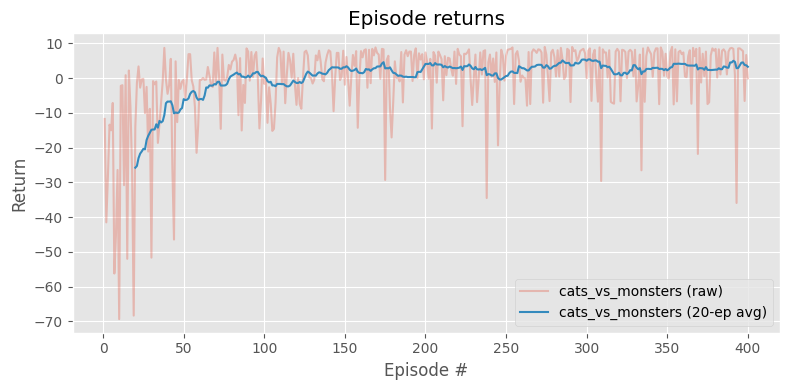

In [38]:
cats_vs_monsters_result = run_reinforce_experiment('cats_vs_monsters')
results['cats_vs_monsters'] = cats_vs_monsters_result
plot_episode_returns({'cats_vs_monsters': cats_vs_monsters_result})

cats_vs_monsters_result


## Mountain Bike experiment


In [39]:
#TODO add mountain bike

## Training diagnostics
Use the helpers below after running experiments to visualize success rate, reward components, and baseline MSE across episodes.

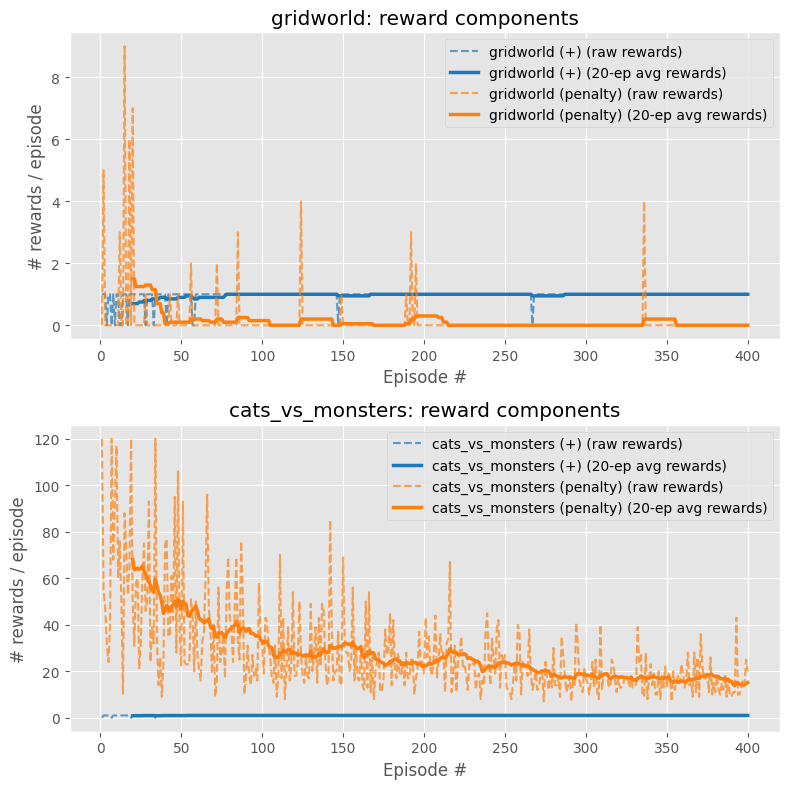

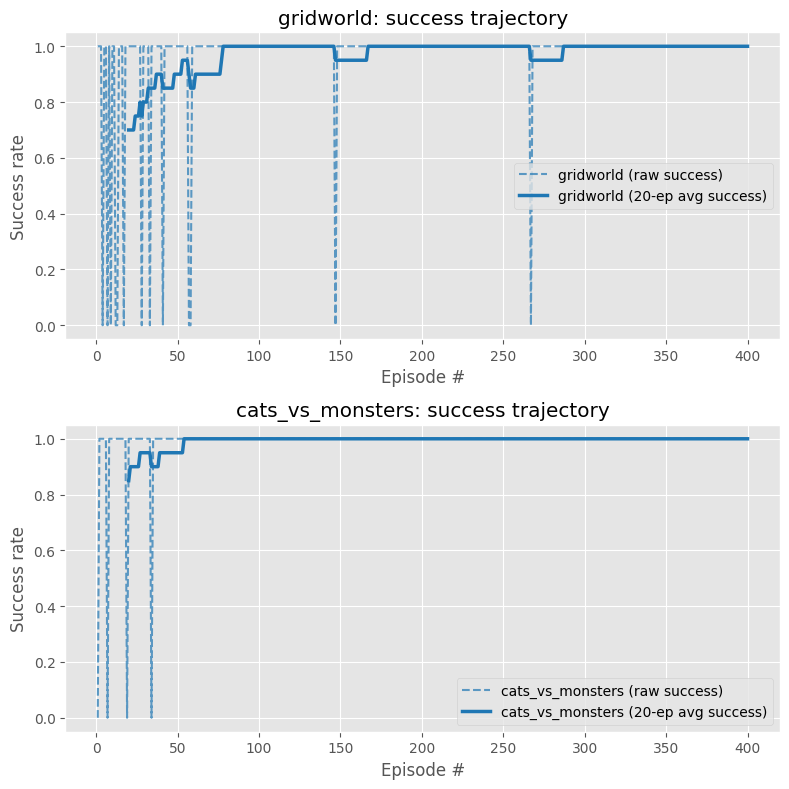

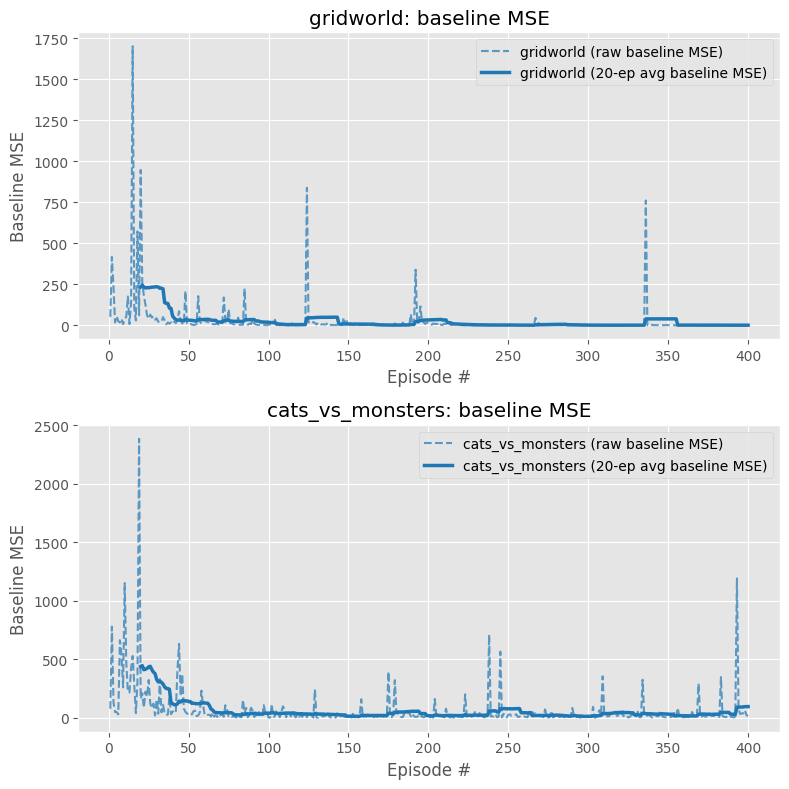

In [40]:
if results:
    plot_reward_components(results)
    plot_success_rate(results)
    plot_baseline_mse(results)
else:
    print("Run an experiment first to generate metrics.")

In [41]:

if not results:
    print('No experiments have been run yet.')
else:
    for env_name, data in results.items():
        returns = np.asarray(data['returns'], dtype=np.float64)
        lengths = np.asarray(data['lengths'], dtype=np.float64)
        success_flags = np.asarray(data.get('success_flags', []), dtype=np.float64)
        positive_counts = np.asarray(data.get('positive_counts', []), dtype=np.float64)
        penalty_counts = np.asarray(data.get('penalty_counts', []), dtype=np.float64)
        baseline_mse = np.asarray(data.get('baseline_mse', []), dtype=np.float64)

        success_rate = success_flags.mean() if success_flags.size else 0.0
        avg_positive = positive_counts.mean() if positive_counts.size else 0.0
        avg_penalty = penalty_counts.mean() if penalty_counts.size else 0.0
        avg_baseline_mse = baseline_mse.mean() if baseline_mse.size else 0.0

        print(f"{env_name}: return mean={returns.mean():.2f} +/- {returns.std():.2f}, max={returns.max():.2f}")
        print(f"           length mean={lengths.mean():.1f}, min={lengths.min():.0f}, max={lengths.max():.0f}")
        print(
            f"           success rate={success_rate * 100:.1f}% | +reward={avg_positive:.1f}, penalties={avg_penalty:.1f}"
        )
        print(f"           baseline MSE mean={avg_baseline_mse:.4f}")
        print('-' * 72)


gridworld: return mean=6.59 +/- 5.76, max=9.32
           length mean=30.4, min=8, max=100
           success rate=96.8% | +reward=1.0, penalties=0.1
           baseline MSE mean=25.9710
------------------------------------------------------------------------
cats_vs_monsters: return mean=0.00 +/- 11.37, max=8.98
           length mean=28.8, min=8, max=120
           success rate=99.0% | +reward=1.0, penalties=27.8
           baseline MSE mean=64.9510
------------------------------------------------------------------------


In [42]:
def load_episode_log(env_key, results_dict=None):
    """Return the saved episode log payload for a recorded experiment."""
    results_dict = results_dict or results
    result = results_dict.get(env_key)
    if result is None:
        raise KeyError(f"No entry named {env_key!r} in results.")

    log_path = result.get('log_path')
    if not log_path:
        print(f"{env_key}: no log path recorded. Rerun run_reinforce_experiment to regenerate logs.")
        return None

    log_file = Path(log_path)
    if not log_file.exists():
        print(f"Log file {log_file} is missing. Rerun the experiment to recreate it.")
        return None

    with log_file.open('r', encoding='utf-8') as fh:
        payload = json.load(fh)

    print(f"Loaded {len(payload.get('logs', []))} episodes from {log_file}")
    return payload
